## Training and Validation Workflow

This notebook presents the results of the other notebooks related to the training and validation workflow.
The workflow is demonstrated using the instance segmentation model.
This notebook is intended as a user guide to provide guidance on how to work with the implemented classes.

The workflow is divided into the following steps:

1. **Load SGY File with DataToolKit class**
    - Create Dataframe for Analyzing and plotting

2. **Analyzing the Data with DataToolKit class**
    - What is the Type of Data 3D or 2D
    - Inspect the Grid of the Data
    - Plotting the Radargrams

3. **Preprocessing with DataToolKit class**
    - Creating a Dataset which can be used for annotation
    - Annotating the Data
    - Connvert Annotations

4. **Train Model on Annotated Data with YOLO**

5. **Validate the Trained Model with YOLO**




First, the working directory is set. This is done for simplicity, so that paths do not need to be entered manually in every method call.
The classes themselves are designed to accept any path as a string.

In [1]:
#Importing used Packages to load the File
import sys
from pathlib import Path

#Setting Working directory
sys.path.append(str(Path.cwd().parent))

#Import the config file so that only the Filename needs to be changed in the _read_segy function
from config import *

### 1 Load SGY File with DataToolKit class

initialize DatatolKit Class

In [2]:
#load and initializie the DataToolKit
from Pipeline.Datatoolkit import DatatoolKit
dk = DatatoolKit(TEST_FILE_DIR, "UG3DQUERUNTERZUG.SGY")


Next step is to load the SGY File

In [3]:
#Load File
sgy_file = dk.LoadSGY()

Next step is to create the DataFrame

In [4]:
sgy_df = dk.create_df(file=sgy_file)

### 2 Analyzing the Data with DataToolKit class

Now the data is analyzed.
The first step is to determine whether the dataset is a 3D or 2D dataset.
Additionally, a pivot table is created to check whether there are unique combinations of inlines and crosslines.

In [7]:
dk.analyse_datetype(df=sgy_df, create_pivot=True)

Inlines: 60, Crosslines: 711
Traces: 42660, Unique Pairs: 42660
Number of duplicated combinations: 0
Datatype: 3D (unique combinations)
crossline  1    2    3    4    5    6    7    8    9    10   ...  702  703  \
inline                                                       ...             
1            1    1    1    1    1    1    1    1    1    1  ...    1    1   
2            1    1    1    1    1    1    1    1    1    1  ...    1    1   
3            1    1    1    1    1    1    1    1    1    1  ...    1    1   
4            1    1    1    1    1    1    1    1    1    1  ...    1    1   
5            1    1    1    1    1    1    1    1    1    1  ...    1    1   
6            1    1    1    1    1    1    1    1    1    1  ...    1    1   
7            1    1    1    1    1    1    1    1    1    1  ...    1    1   
8            1    1    1    1    1    1    1    1    1    1  ...    1    1   
9            1    1    1    1    1    1    1    1    1    1  ...    1    1   
10    

A grid can also be plotted, which provides an indication of the data density and how the traces are structured.

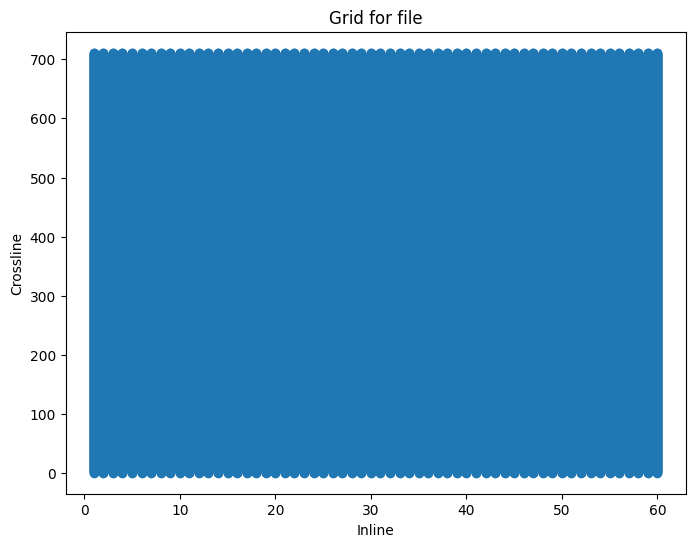

In [8]:
dk.plot_grid(df=sgy_df)

The next step is to inspect the radargrams to determine which ones may be useful for annotating polygons corresponding to hyperbolas.
In this plot, a specific cut_number can be selected, and for each type of cut, four example radargrams are displayed.

Plotting Inline_cuts

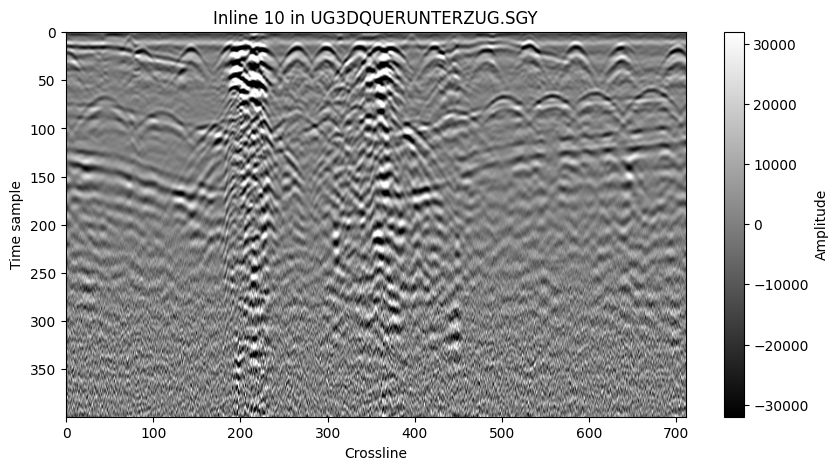

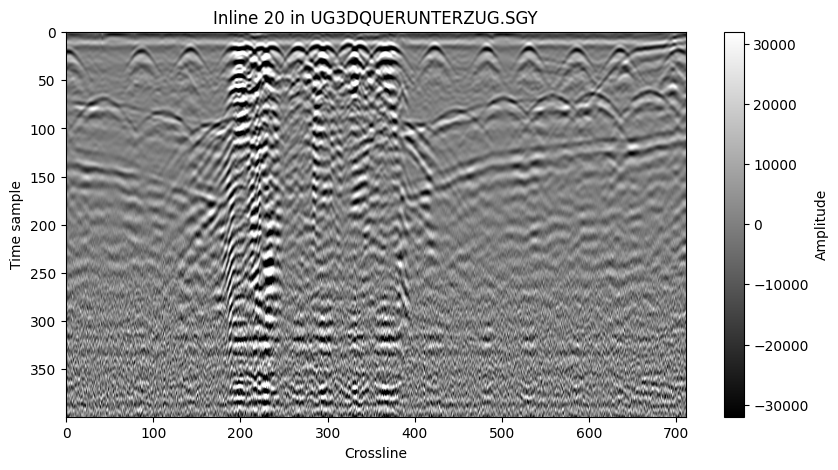

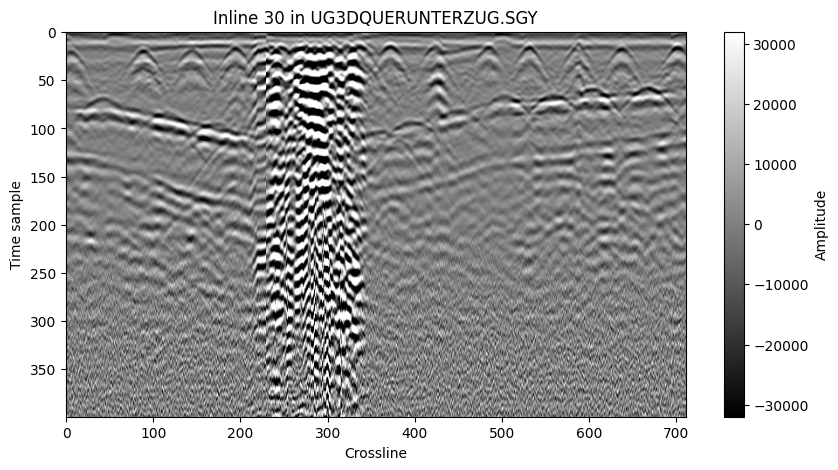

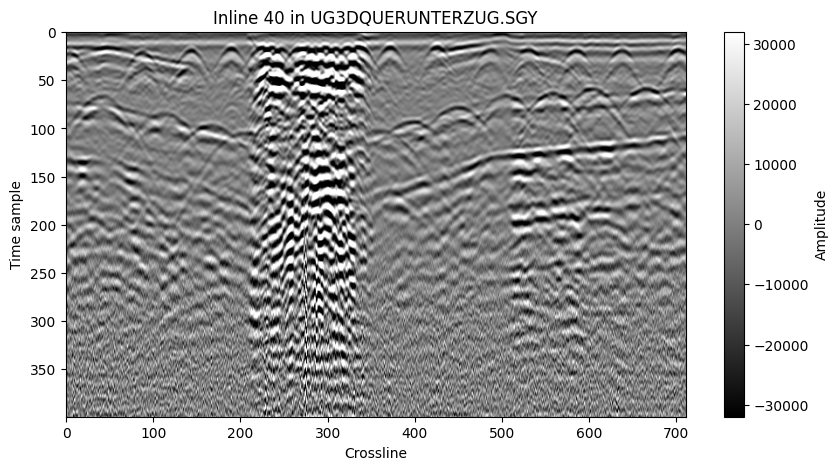

In [9]:
dk.plot_inline_cut_raw(df = sgy_df, inlinenr = 10)
dk.plot_inline_cut_raw(df = sgy_df, inlinenr = 20)
dk.plot_inline_cut_raw(df = sgy_df, inlinenr = 30)
dk.plot_inline_cut_raw(df = sgy_df, inlinenr = 40)

Nextstep is Plotting the crossline cuts

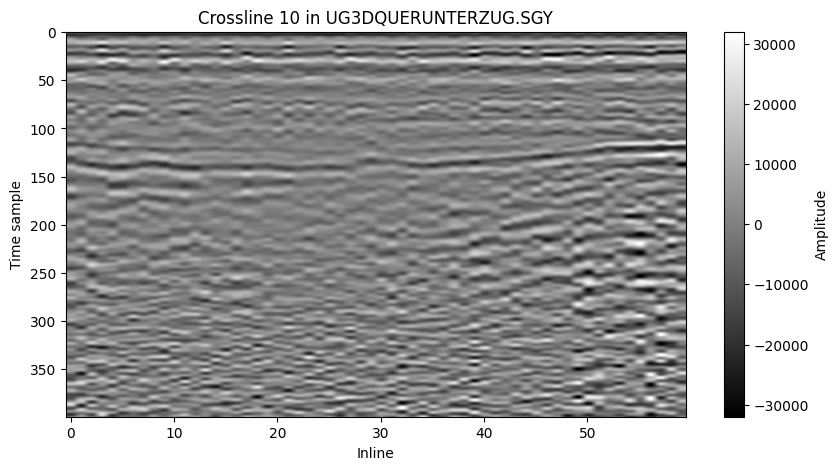

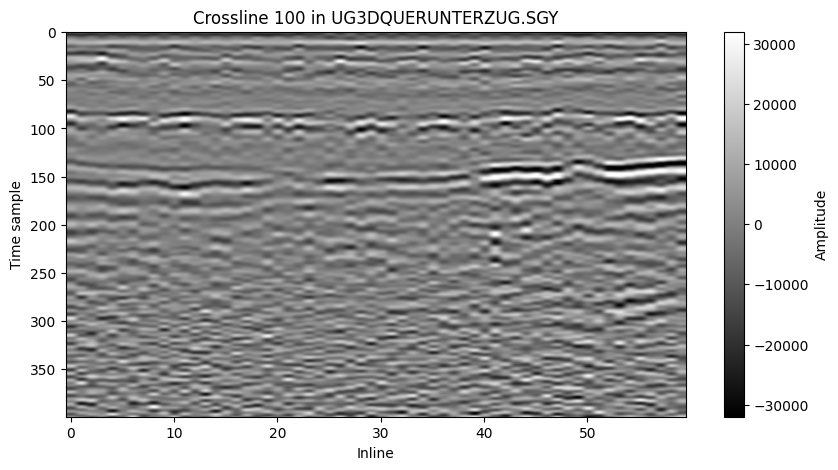

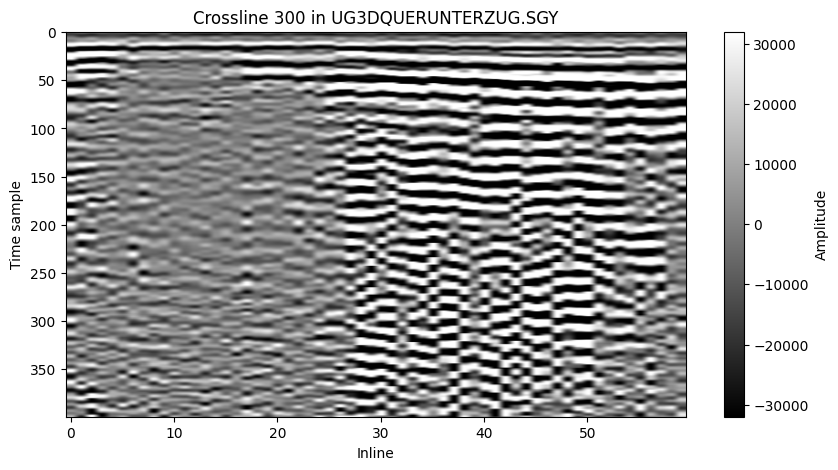

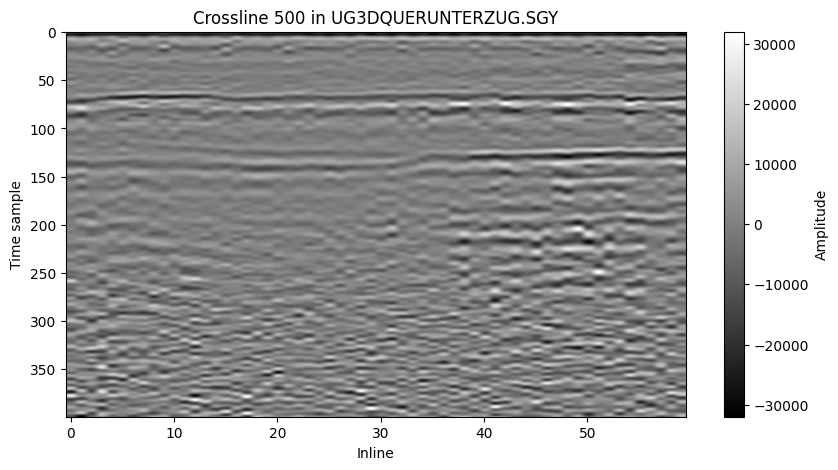

In [10]:
dk.plot_crossline_cut_raw(df = sgy_df, cross_nr = 10)
dk.plot_crossline_cut_raw(df = sgy_df, cross_nr = 100)
dk.plot_crossline_cut_raw(df = sgy_df, cross_nr = 300)
dk.plot_crossline_cut_raw(df = sgy_df, cross_nr = 500)

next is to plot the timeslice Plots

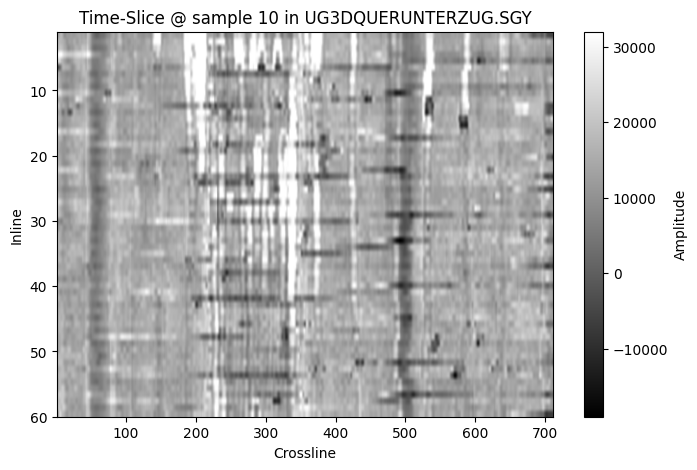

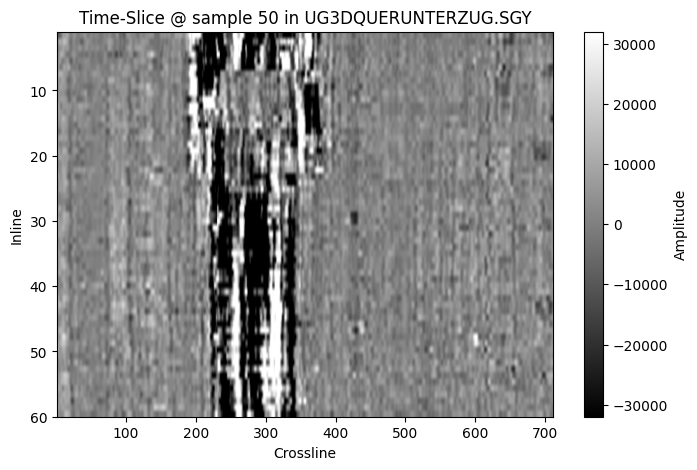

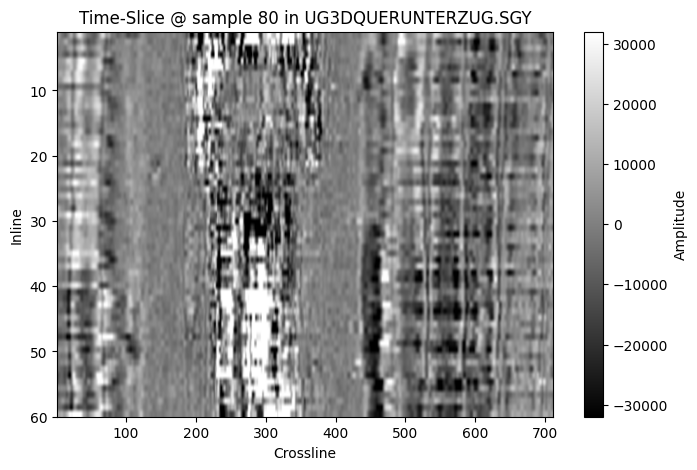

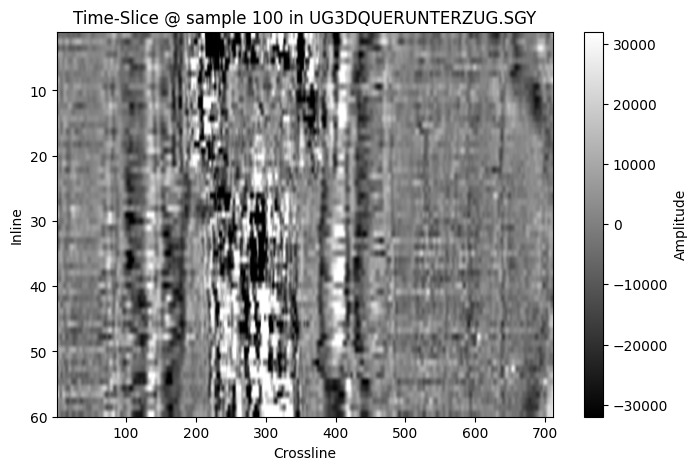

In [11]:
dk.plot_timeslice_cut_raw(df = sgy_df, sample_index= 10)
dk.plot_timeslice_cut_raw(df = sgy_df, sample_index= 50)
dk.plot_timeslice_cut_raw(df = sgy_df, sample_index= 80)
dk.plot_timeslice_cut_raw(df = sgy_df, sample_index= 100)

### Preprocessing with DataToolKit class

The only remaining step is to create images from the data, since normalization is handled by YOLO during training.
Because the inline cuts appear to be the most promising for the task of instance segmentation of hyperbolas, the images are generated using these cuts.

In [10]:
dk.create_images(file= sgy_file, df= sgy_df, outdir=PICTURES_FOR_ANNOTATION , inline = True)

saved 60 images to c:\vscode\PAINDGPR\Data\Data_for_Models\Pictures\UG3DQUERUNTERZUG.SGY_inline_60.png


Annotation was performed using Roboflow, a free tool for annotating images for various detection tasks.
The images created beforehand can be uploaded to Roboflow and annotated there.
Once the annotation is complete, a dataset can be generated and automatically split into train/val/test.
This dataset can then be downloaded and saved in SEG_RAW (or any other desired path).

In SEG_RAW, some data from the initial training already exist; these files can be deleted or moved if necessary.

After the dataset has been placed in SEG_RAW, the converter class can be used to convert the annotations into a YOLO-compatible format.
The converter also accepts a parameter specifying where the converted segmentations should be saved—either directly into the folder of the chosen model type or into any other directory.

For each model type, there is a corresponding folder in Annotated_Data, which now contains the data used for the initial training as well as the YAML file.
Instructions on how to set up this YAML file are documented in 8_Training_Validating_Tune_Yolo_Model.ipynb.
The required folder structure for YOLO training is also described in that notebook.

In [ ]:
from Pipeline.Segmentation_converter import CocoConverter

conv = CocoConverter(raw_segmentation_path="path to unconvertet Segmentation", save_segmentation_path="path to converted Segmentations")
conv.run()

Annotations C:\Users\Joris Gisler\Downloads\Paind.v1i.coco-segmentation\test\_annotations.coco.json: 100% ━━━━━━━━━━━━ 3/3 358.9it/s 0.0s
COCO data converted successfully.
Results saved to C:\Users\Joris Gisler\Downloads\test


### 4 Train Model with Annotated Data with YOLO

If the structure described earlier is set up correctly, the training can be executed.
For this purpose, training scripts have been implemented.
The most important step is to correctly set the path to the YAML file — without it, the training cannot start.

Below is an example for an instance segmentation training setup.
Do not run this from within a Jupyter Notebook, because i tried it and it crashed during execution.

In [ ]:
#Setting Working directory
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

#Import the config file so that only the Filename needs to be changed in the _read_segy function
from config import *

from ultralytics import YOLO

#load pretrained model
model = YOLO("yolo11n-seg.pt")

#train on custom dataset
#data = is the path to the yaml file
results = model.train(data=YOLO_MODEL_SEG_H_YAML,epochs = 200,batch=4 ,project="YOLO_Model_seg", name="Hyperbola_seg")


        



### 5 Validating Trained Model

During training, a results.csv file is generated, which can be used to evaluate how well the model has learned.
The following code produces a simple plot that visualizes the most important metrics.
This helps in assessing issues such as overfitting.
The example shown here is based on the instance segmentation model for hyperbolas.

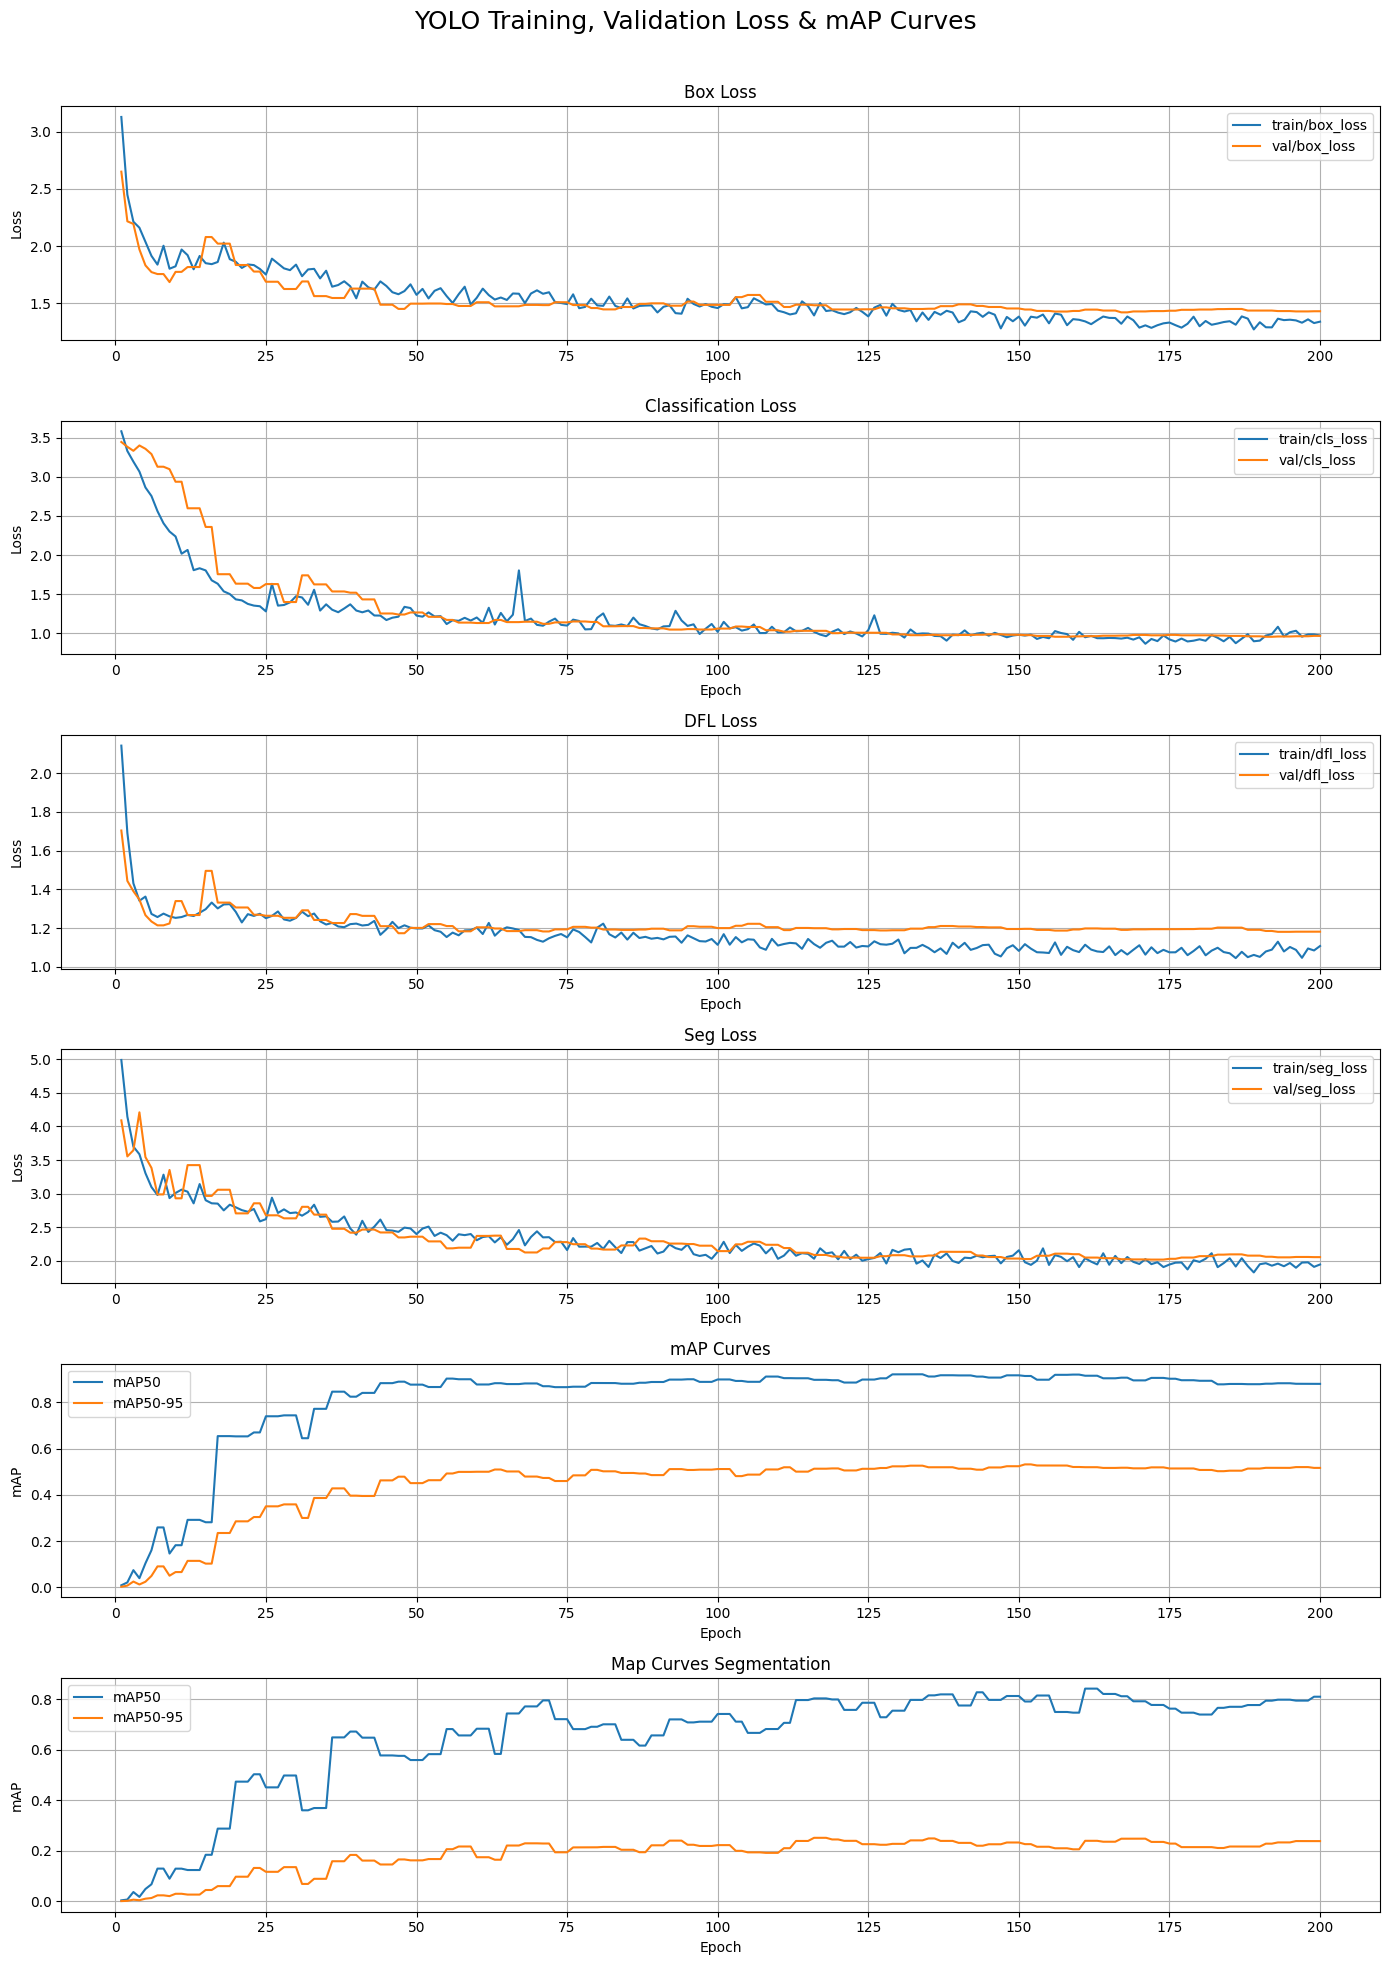

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# CSV laden
df = pd.read_csv(BASE_DIR / "YOLO_Model_seg/Hyperbola_seg/results.csv")

# Plot-Größe
fig, axs = plt.subplots(6, 1, figsize=(14, 20))
fig.suptitle("YOLO Training, Validation Loss & mAP Curves", fontsize=18)

#box loss
axs[0].plot(df["epoch"], df["train/box_loss"], label="train/box_loss")
axs[0].plot(df["epoch"], df["val/box_loss"], label="val/box_loss")
axs[0].set_title("Box Loss")
axs[0].set_xlabel("Epoch")
axs[0].set_ylabel("Loss")
axs[0].legend()
axs[0].grid()

#classification loss
axs[1].plot(df["epoch"], df["train/cls_loss"], label="train/cls_loss")
axs[1].plot(df["epoch"], df["val/cls_loss"], label="val/cls_loss")
axs[1].set_title("Classification Loss")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Loss")
axs[1].legend()
axs[1].grid()

#dfl loss
axs[2].plot(df["epoch"], df["train/dfl_loss"], label="train/dfl_loss")
axs[2].plot(df["epoch"], df["val/dfl_loss"], label="val/dfl_loss")
axs[2].set_title("DFL Loss")
axs[2].set_xlabel("Epoch")
axs[2].set_ylabel("Loss")
axs[2].legend()
axs[2].grid()

#seg_loss
axs[3].plot(df["epoch"], df["train/seg_loss"], label="train/seg_loss")
axs[3].plot(df["epoch"], df["val/seg_loss"], label="val/seg_loss")
axs[3].set_title("Seg Loss")
axs[3].set_xlabel("Epoch")
axs[3].set_ylabel("Loss")
axs[3].legend()
axs[3].grid()


#map boxes
axs[4].plot(df["epoch"], df["metrics/mAP50(B)"], label="mAP50")
axs[4].plot(df["epoch"], df["metrics/mAP50-95(B)"], label="mAP50-95")
axs[4].set_title("mAP Curves")
axs[4].set_xlabel("Epoch")
axs[4].set_ylabel("mAP")
axs[4].legend()
axs[4].grid()

#map masks
axs[5].plot(df["epoch"], df["metrics/mAP50(M)"], label="mAP50")
axs[5].plot(df["epoch"], df["metrics/mAP50-95(M)"], label="mAP50-95")
axs[5].set_title("Map Curves Segmentation")
axs[5].set_xlabel("Epoch")
axs[5].set_ylabel("mAP")
axs[5].legend()
axs[5].grid()

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


The following metrics can be evaluated using the test set.
It is good practice to validate a model on data it has never seen before.

- **Precision-Confidence Curve**
- **Recall- Confidence Curve**
- **Precision and Recall Curve**
- **F1-Score**
- **Confusion Matrix**

With YOLO, it is possible to validate on a completely unseen dataset.
Note: To validate on an unseen dataset, the data must be annotated, converted beforehand, and arranged in the correct folder structure.

The best practice is to validate on a test set that was created during the Roboflow split.
The corresponding code for Validation on a test set is shown below.

In [5]:
#Validation Object Detection

from ultralytics import YOLO

#load model
model_od = YOLO(YOLO_MODEL_SEG_H_DIR) #Path to Model

#validate model
#data = Path to yaml
metrics_od = model_od.val(data = YOLO_MODEL_SEG_H_YAML, split="test")

Ultralytics 8.3.208  Python-3.11.13 torch-2.8.0+cpu CPU (11th Gen Intel Core(TM) i5-1135G7 2.40GHz)
YOLO11n-seg summary (fused): 113 layers, 2,834,763 parameters, 0 gradients, 9.6 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 376.2270.1 MB/s, size: 34.6 KB)
val: Scanning C:\pythonad\PAINDHS25\PAINDGPR\Annotated_Data\YOLO_Segmentation_Hyperbola\test\labels.cache... 4 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4/4  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.1it/s 0.9s
                   all          4         93      0.816      0.903      0.926      0.507      0.715      0.796      0.735      0.218
Speed: 3.0ms preprocess, 125.3ms inference, 0.0ms loss, 63.7ms postprocess per image
Results saved to C:\pythonad\PAINDHS25\PAINDGPR\Notebooks\runs\segment\val2


The Validation then gets saved to /runs/{modelytype}/val

The next step would be to tune the Model which is explained in **8 Training_Evaluate_Tune_Yolo_Model.ipynb**. But this was note done in this work it is only shown how it could be done.